# Measuring PDSCH Bit Error Rate (BER)

This notebook demonstrates how to use **NeoRadium** to measure the bit error rate (BER) of an end-to-end downlink PDSCH transmission chain without channel coding.

The simulation generates random transport bits, maps them onto a PDSCH resource grid, applies precoding and a CDL fading channel, adds AWGN, performs channel estimation and equalization at the receiver, and finally recovers the transmitted bits through QAM demodulation. The recovered bits are compared with the transmitted bits to calculate BER.

The notebook evaluates BER across a range of SNR values and compares two receiver assumptions:

- **Perfect channel knowledge**
- **Least-Squares (LS) channel estimation**

The resulting BER curves illustrate the impact of channel-estimation accuracy on uncoded PDSCH performance.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

from neoradium import Carrier, PDSCH, CdlChannel, AntennaPanel, random


Simulating the end-to-end pipeline for 16QAM using Perfect channel knowledge in the frequency domain
SNR(dB)   Total Bits   Bit Errors   BER(%)    Time (s) 
-------   ----------   ----------   ------   ----------
  -20       2995200       869485     29.03      7.83
  -15       2995200       565385     18.88      7.48
  -10       2995200       296600      9.90      7.68
   -5       2995200       115669      3.86      7.53
    0       2995200        12637      0.42      7.64
    5       2995200           35      0.00      7.80

Simulating the end-to-end pipeline for 16QAM using LS channel estimation in the frequency domain
SNR(dB)   Total Bits   Bit Errors   BER(%)    Time (s) 
-------   ----------   ----------   ------   ----------
  -20       2995200      1055935     35.25      7.69
  -15       2995200       742567     24.79      7.71
  -10       2995200       412265     13.76      7.69
   -5       2995200       185711      6.20      7.79
    0       2995200        43406      1.45    

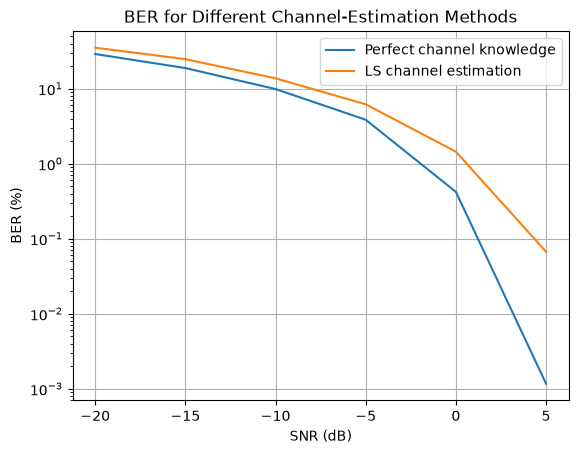

In [2]:
numFrames = 5                               # Number of time-domain frames
snrDbs = [-20,-15,-10,-5,0,5]               # SNR values, in dB, used for evaluation
freqDomain = True                           # Set to False to apply channel in the time domain

modulation = "16QAM"                        # Modulation scheme
carrier = Carrier(numRbs=24, spacing=30)    # Create a carrier with 24 RBs and 30 kHz subcarrier spacing
bwp = carrier.curBwp                        # The single bandwidth part in the carrier

# Create a PDSCH object
pdsch = PDSCH(bwp, numLayers=2, modulation=modulation)
pdsch.setDMRS(configType=2, additionalPos=2)            # DMRS configuration

numSlots = bwp.slotsPerFrame*numFrames                  # Total number of slots
results = {}                                            # Dictionary to save the results

minMse, maxMse = 100, 0
for chanEstMethod in ["Perfect channel knowledge", "LS channel estimation"]:    # Two channel estimation methods
    results[chanEstMethod] = {}
    print("\nSimulating the end-to-end pipeline for %s using %s in the %s domain"%
          (modulation, chanEstMethod, "frequency" if freqDomain else "time"))
    print("SNR(dB)   Total Bits   Bit Errors   BER(%)    Time (s) ")
    print("-------   ----------   ----------   ------   ----------")
    for snrDb in snrDbs:
        random.setSeed(123)             # Reset the random seed for reproducible results at each SNR
        t0 = time.monotonic()
        carrier.slotNo = 0

        # Create a CdlChannel object
        channel = CdlChannel(bwp, 'C', delaySpread=300, carrierFreq=4e9, dopplerShift=5,
                             txAntenna = AntennaPanel([2,4], polarization="x"),  # 16 TX antennas
                             rxAntenna = AntennaPanel([1,2], polarization="x"))  # 4 RX antennas

        bitErrors = 0
        totalBits = 0

        for slotNo in range(numSlots):
            pdsch.initGrid()                            # Create and initialize PDSCH's internal grid
            numBits = pdsch.getBitCapacity()            # Number of bits available in the resource grid
            txBits = random.bits(numBits[0])            # Create random binary data

            # Populate the resource grid with the random data. This includes QAM modulation and resource mapping.
            pdsch.setPdschData(txBits)

            channelMatrix = channel.getChannelMatrix()              # Get the channel matrix
            precoder = pdsch.getPrecodingMatrix(channelMatrix)      # Get the precoder matrix

            txGrid = bwp.createGrid(len(channel.txAntenna))         # Create the transmitted resource grid
            pdsch.precodeTo(txGrid, precoder)                       # Perform the precoding
            
            if freqDomain:
                rxGrid = txGrid.applyChannel(channelMatrix)                 # Apply the channel in the frequency domain
                rxGrid = rxGrid.addNoise(snrDb=snrDb)                       # Add noise
            else:
                txWaveform = txGrid.ofdmModulate()                          # OFDM modulation
                maxDelay = channel.getMaxDelay()                            # Get the maximum channel delay
                txWaveform = txWaveform.pad(maxDelay)                       # Pad with zeros
                rxWaveform = channel.applyToSignal(txWaveform)              # Apply channel in time domain
                noisyRxWaveform = rxWaveform.addNoise(snrDb=snrDb, bwp=bwp) # Add noise
                offset = channel.getTimingOffset()                          # Get timing information for synchronization
                syncedWaveform = noisyRxWaveform.sync(offset)               # Synchronization
                rxGrid = syncedWaveform.ofdmDemodulate(bwp)                 # OFDM demodulation

            if "Perfect" in chanEstMethod:
                estChannelMat = channel.getEffChannel(channelMatrix, precoder)      # Perfect channel knowledge
                eqGrid, llrScales = pdsch.equalize(rxGrid, estChannelMat)           # Equalization
            else:                                                                 
                estChannelMat, errVar = pdsch.estimateChannel(rxGrid)               # LS channel estimation
                eqGrid, llrScales = pdsch.equalize(rxGrid, estChannelMat, errVar)   # Equalization
            
            rxBits = pdsch.getHardBits(eqGrid)[0]                           # Recover hard bits from the equalized grid
            bitErrors += np.abs(rxBits-txBits).sum()                        # Count the number of bit errors
            totalBits += numBits[0]
            print("\r  %3d      %8d     %8d    %6.2f    %6.2f"%(snrDb, totalBits, bitErrors, 
                                                                bitErrors*100/totalBits, time.monotonic()-t0), end='')

            channel.goNext()                        # Prepare the channel model for the next slot

        dt = time.monotonic()-t0                    # Total simulation time for this SNR
        results[chanEstMethod][snrDb] = {"totalBits":totalBits, 
                                         "bitErrors":bitErrors, 
                                         "BER":      bitErrors*100/totalBits,
                                         "Time":     dt,
                                         "NoiseVar": rxGrid.noiseVar}
        print("\r  %3d      %8d     %8d    %6.2f    %6.2f"%(snrDb, totalBits, bitErrors, 
                                                            bitErrors*100/totalBits, dt))

# Compare the results
for i,chanEstMethod in enumerate(["Perfect channel knowledge", "LS channel estimation"]):
    bers = [results[chanEstMethod][snrDb]["BER"] for snrDb in snrDbs]
    plt.plot(snrDbs, bers, label=chanEstMethod)
plt.legend()
plt.title("BER for Different Channel-Estimation Methods");
plt.grid()
plt.xlabel("SNR (dB)")
plt.xticks(snrDbs)
plt.ylabel("BER (%)")
plt.yscale('log')
plt.show()